In [1]:
from SystematicScanOfConvergence.MakeHam import *
# from Permutations.Helpers import *
from Permutations.Helpers import *
import matplotlib.pyplot as plt
from math import factorial
from scipy.sparse.linalg import eigsh
from Permutations.SKQD import *
from Permutations.PowerSampling import *
from Permutations.CSRtoSPO import *
from BARK import *
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import tqdm
from scipy.sparse import csr_matrix
from qiskit.quantum_info import Operator
from qiskit.quantum_info import SparsePauliOp
from new_approach.Hamiltonian_controlled_sparsity import make_controlled_sparse_ground_state_hamiltonian_from_qubits, make_controlled_sparse_ground_state_hamiltonian_fast

# Create Hamiltonian with arbitrary sparsity and arbitrarily sparse GS

In [ ]:
H, H_spo, psi, support, info = (
    make_controlled_sparse_ground_state_hamiltonian_fast(
        n_qubits=8,
        ground_state_sparsity=0.15,
        hamiltonian_sparsity=0.5,
        seed=123,
        ground_energy=0.0,
        gap=1.0,
        return_info=True,
    )
)

# print(type(H_csr))
# print(type(H_pauli))
# print(info["num_pauli_terms"])

In [49]:
correct_energy, correct_state = eigsh(H, k=1, which='SA')
# Sparsity of the correct ground state
amps = np.abs(correct_state[:, 0]) ** 2
sparsity = np.sum(amps > 1e-14) / len(amps)
print(f"Sparsity of the correct ground state: {sparsity:.4f}")

Sparsity of the correct ground state: 0.1523


In [50]:
n_steps = 16
initial = np.argmax(amps)

initial_state = np.zeros(H.shape[0])
initial_state[initial] = 1

print(f"Initial overlap with correct state: {np.abs(np.dot(correct_state[:, 0].conj(), initial_state)):.4f}")

Initial overlap with correct state: 0.3820


# SKQD for different time steps

In [51]:
skqd_list0001 = do_skqd(H, n_steps, t = 0.001, initial=initial)
skqd_list001 = do_skqd(H, n_steps, t = 0.01, initial=initial)
skqd_list01 = do_skqd(H, n_steps, t = 0.1, initial=initial)
skqd_list02 = do_skqd(H, n_steps, t = 0.2, initial=initial)
skqd_list03 = do_skqd(H, n_steps, t = 0.3, initial=initial)
skqd_list04 = do_skqd(H, n_steps, t = 0.4, initial=initial)
skqd_list05 = do_skqd(H, n_steps, t = 0.5, initial=initial)
skqd_list06 = do_skqd(H, n_steps, t = 0.6, initial=initial)
skqd_list07 = do_skqd(H, n_steps, t = 0.7, initial=initial)
skqd_list08 = do_skqd(H, n_steps, t = 0.8, initial=initial)
skqd_list09 = do_skqd(H, n_steps, t = 0.9, initial=initial)
skqd_list10 = do_skqd(H, n_steps, t = 1.0, initial=initial)

100%|██████████| 16/16 [00:00<00:00, 1063.04it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1127.22it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1022.58it/s]


...

No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1142.71it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1034.77it/s]

No more indices left to sample.


In [52]:
print(type(H), type(skqd_list0001))

<class 'scipy.sparse._csr.csr_matrix'> <class 'numpy.ndarray'>


In [53]:
skqd_path01 = get_one_path(H, skqd_list01)
skqd_path02 = get_one_path(H, skqd_list02)
skqd_path03 = get_one_path(H, skqd_list03)
skqd_path04 = get_one_path(H, skqd_list04)
skqd_path05 = get_one_path(H, skqd_list05)
skqd_path06 = get_one_path(H, skqd_list06)
skqd_path07 = get_one_path(H, skqd_list07)
skqd_path08 = get_one_path(H, skqd_list08)
skqd_path09 = get_one_path(H, skqd_list09)
skqd_path10 = get_one_path(H, skqd_list10)
skqd_path001 = get_one_path(H, skqd_list001)
skqd_path0001 = get_one_path(H, skqd_list0001)

# Get the rest of the paths

In [54]:
Paths = get_all_paths(H, 20, initial)

Computing paths: 100%|██████████| 20/20 [01:59<00:00,  6.00s/it]


# Helpers

In [55]:
# Helpers

def bitstrings_to_indices(basis: List[str]) -> List[int]:
    return [int(b, 2) for b in basis]

def get_one_path_from_BK(basis_list: List[str]) -> List[str]:
    energies = []
    for pos in tqdm.tqdm(range(len(basis_list))):
        current_basis = basis_list[:pos+1]
        indices = bitstrings_to_indices(current_basis)
        H_proj = project_down(H, indices)

        if pos > 2:
            energies.append(eigsh(H_proj, k=1, which='SA', return_eigenvectors=False)[0])
        else:
            energies.append(eigh(H_proj.toarray(), eigvals_only=True)[0])

    return energies

# Bark

In [56]:
from Permutations.Bark_2_0 import BarkBarkBark

In [57]:
# get initial state for bark
initial_bark = format(initial, '0' + str(int(np.log2(H.shape[0]))) + 'b')

In [117]:
explorer = BarkBarkBark(
    H=H_spo,
    initial_state=initial_bark,
    keep_states=70,            # M
    max_applications=15,      # number of H-applications to selected batches
    mode="top_m",             # or "importance_sample"
    sample_size=1,           # only used for importance_sample
    sampling_score="amplitude",
    return_only_applied_bitstrings=True,
    random_seed=123,
)

bitstrings = explorer.run()
print(len(bitstrings))

print(bitstrings)

256
['11101000', '00000011', '01000111', '01101010', '11010101', '11001010', '00100110', '01010010', '01001001', '11011101', '10001010', '01011001', '10011111', '10000101', '10010000', '10110111', '11011000', '01010001', '00111001', '00000111', '01010110', '00111111', '00000110', '00000101', '10011011', '00111000', '10011000', '11011111', '11110110', '00101111', '01110100', '10000000', '11001111', '01100010', '00100010', '01110011', '10000010', '00001111', '10011100', '01111010', '10010101', '01000010', '01001100', '11111001', '01011100', '10101010', '10110101', '10101101', '11111011', '11001001', '01000100', '00101001', '11111100', '01001010', '10001100', '00011000', '00101010', '10111101', '00010001', '00000100', '00110001', '10101011', '01100001', '10101111', '01111111', '00000001', '11111110', '00010100', '00111110', '00110110', '01011000', '10101110', '10111100', '01000101', '10001111', '01010101', '11110111', '11100011', '11111000', '11100111', '01001000', '00100001', '01101011',

In [118]:
BK_BK_BK_path = get_one_path_from_BK(bitstrings)

100%|██████████| 256/256 [00:03<00:00, 73.75it/s] 


In [119]:
# BK_BK_BK_path[0]=0

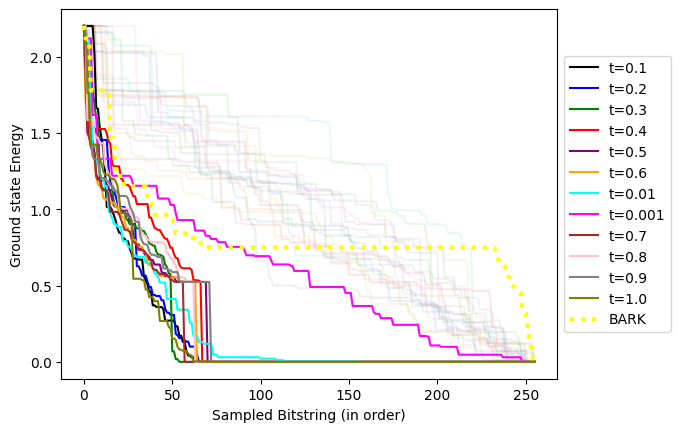

In [120]:
i = 0
for path in Paths:
    plt.plot(path, alpha=0.1)
    i += 1
plt.plot(skqd_path01, label='t=0.1', color='black')
plt.plot(skqd_path02, label='t=0.2', color='blue')
plt.plot(skqd_path03, label='t=0.3', color='green')
plt.plot(skqd_path04, label='t=0.4', color='red')
plt.plot(skqd_path05, label='t=0.5', color='purple')
plt.plot(skqd_path06, label='t=0.6', color='orange')
plt.plot(skqd_path001, label='t=0.01', color='cyan')
plt.plot(skqd_path0001, label='t=0.001', color='magenta')
plt.plot(skqd_path07, label='t=0.7', color='brown')
plt.plot(skqd_path08, label='t=0.8', color='pink')
plt.plot(skqd_path09, label='t=0.9', color='gray')
plt.plot(skqd_path10, label='t=1.0', color='olive')
# plt.plot(power_path, label='Power Sampling', color='purple', linestyle='dashed')
# plt.plot(BK_path, label='BARK', color='purple', linestyle='dotted')
plt.plot(BK_BK_BK_path, label='BARK', color='yellow',linewidth=3.0, linestyle='dotted')
# Make legend next to plot
plt.ylabel('Ground state Energy')
plt.xlabel('Sampled Bitstring (in order)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))